# SOM — Mapa de Perfiles de Futbolistas

---

**Autor:** Borja Mora Méndez  
**Contacto:** borja.mora.mendez@gmail.com · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)  
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)  
**Categoría:** Machine Learning · No supervisado · Redes Neuronales · SOM  
**Dataset:** `jugadores_futbol.xlsx` · 800 jugadores · 6 atributos de rendimiento

---

### Objetivo

Utilizar un **Self-Organizing Map (SOM)** para descubrir cómo se distribuyen los perfiles de rendimiento de los futbolistas en un espacio 2D y comprobar si esa estructura coincide con las posiciones reales.

### Contexto de negocio

El departamento de scouting necesita analizar cientos de jugadores sin depender únicamente de filtros individuales. El SOM permite convertir seis dimensiones de rendimiento en un **mapa visual de perfiles**, facilitando la detección de arquetipos, zonas de transición y jugadores potencialmente versátiles.


## 1️. Setup: librerías y configuración visual

In [18]:
# Librerías base

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración general
pd.set_option("display.max_columns", None)

# Estilo visual común del portfolio
PURPLE = "#7a7bff"
GREEN  = "#6E7F5B"
RED    = "#C2412E"
GRAY   = "#F4EFE6"
INK    = "#2B2118"
MUTED  = "#bfbfbf"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})


## 2. Carga de datos


In [19]:
# Carga del dataset
df = pd.read_excel("jugadores_futbol.xlsx")

# Normalizar nombres de columnas
df.columns = [c.replace("í", "i") for c in df.columns]

atributos = [
    "Velocidad", "Tiro", "Regate",
    "Pase", "Defensa", "Fisico"
]

print(f"Registros: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Posiciones: {df['Posicion_Real'].nunique()}")
df.head()


Registros: 800
Columnas: 7
Posiciones: 3


,Velocidad,Tiro,Regate,Pase,Defensa,Fisico,Posicion_Real
0,68.476999,39.032150,54.533820,75.661209,83.360926,78.361041,Defensa
1,76.054490,45.372043,46.713679,68.797920,81.756076,76.739892,Defensa
2,66.693736,26.607038,37.925575,61.063987,77.910182,82.199731,Defensa
3,58.643831,30.113874,60.259541,63.419566,85.472697,70.026763,Defensa
4,61.189321,40.776458,41.943045,67.629886,80.795529,77.958144,Defensa


## 3. EDA: Análisis Exploratorio de Datos

Antes de entrenar el SOM comprobamos la calidad de los datos, la distribución de los atributos y las diferencias entre posiciones.

La posición real **no entra en el modelo**: se utilizará después como etiqueta de validación para comprobar si el mapa descubre una estructura coherente.


In [20]:
# Tipos, nulos y valores únicos
info = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(2),
    "Únicos": df.nunique()
})

info


,Tipo,Nulos,% Nulos,Únicos
Velocidad,float64,0,0.0,800
Tiro,float64,0,0.0,800
Regate,float64,0,0.0,798
Pase,float64,0,0.0,800
Defensa,float64,0,0.0,794
Fisico,float64,0,0.0,799
Posicion_Real,object,0,0.0,3


In [21]:
# Estadísticos descriptivos
df[atributos].describe().round(2)


,Velocidad,Tiro,Regate,Pase,Defensa,Fisico
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,72.12,59.31,68.11,73.44,62.87,73.12
std,9.42,17.33,15.89,10.71,20.54,8.89
min,50.15,19.55,31.44,44.73,16.95,49.22
25%,65.26,43.06,52.39,65.36,47.03,66.58
50%,70.88,62.58,71.92,72.47,62.63,72.63
75%,79.18,73.85,80.18,81.97,81.33,78.93
max,99.00,92.25,99.00,99.00,99.00,99.00


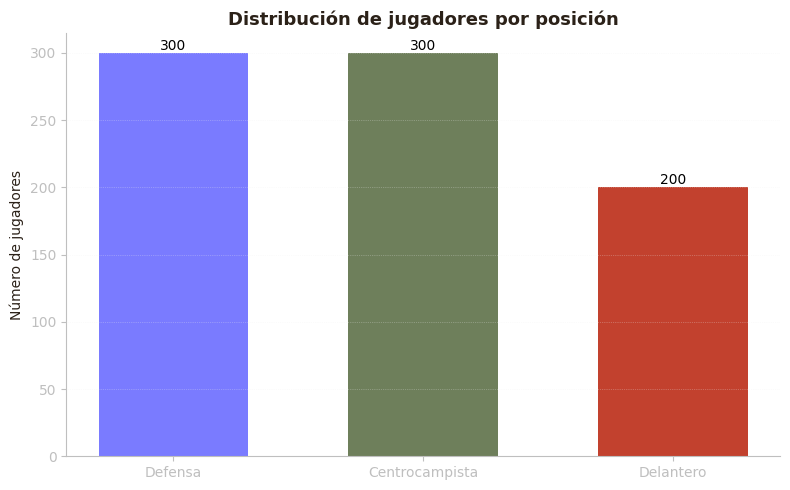

In [22]:
# Distribución de posiciones
conteo_pos = df["Posicion_Real"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    conteo_pos.index,
    conteo_pos.values,
    color=[PURPLE, GREEN, RED],
    width=0.6
)

ax.set_title("Distribución de jugadores por posición")
ax.set_ylabel("Número de jugadores")
ax.grid(axis="y", linestyle=":", alpha=0.5)

for bar, value in zip(bars, conteo_pos.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value}",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()


### Distribución de atributos por posición

Estas distribuciones permiten comprobar qué habilidades diferencian a los perfiles antes de construir el mapa.


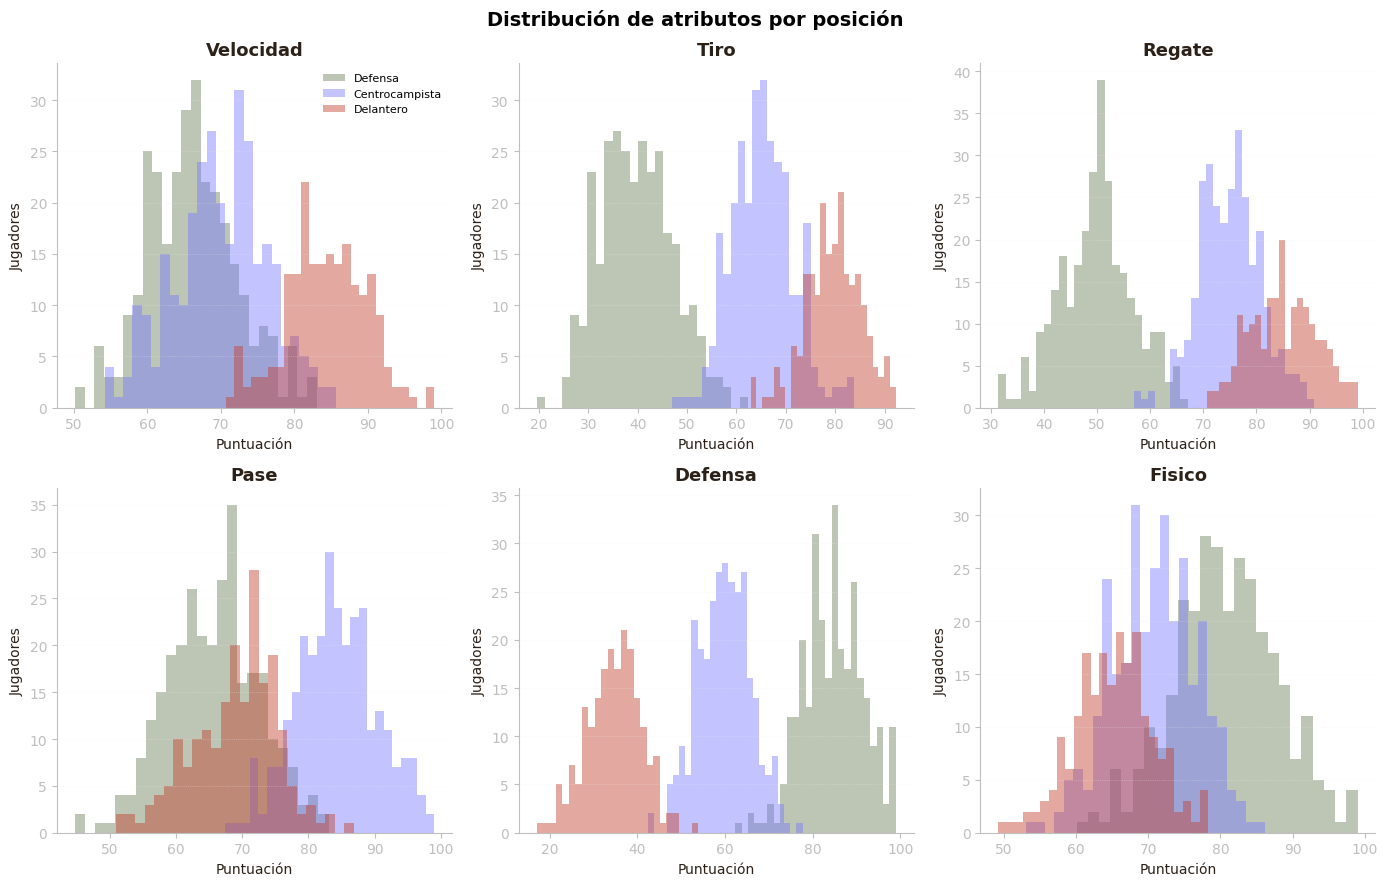

In [23]:
# Distribución de cada atributo por posición
colores_pos = {
    "Defensa": GREEN,
    "Centrocampista": PURPLE,
    "Delantero": RED
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, attr in zip(axes.flat, atributos):
    for pos, color in colores_pos.items():
        subset = df.loc[df["Posicion_Real"] == pos, attr]
        ax.hist(
            subset,
            bins=25,
            alpha=0.45,
            label=pos,
            color=color
        )
    ax.set_title(attr)
    ax.set_xlabel("Puntuación")
    ax.set_ylabel("Jugadores")
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Distribución de atributos por posición", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


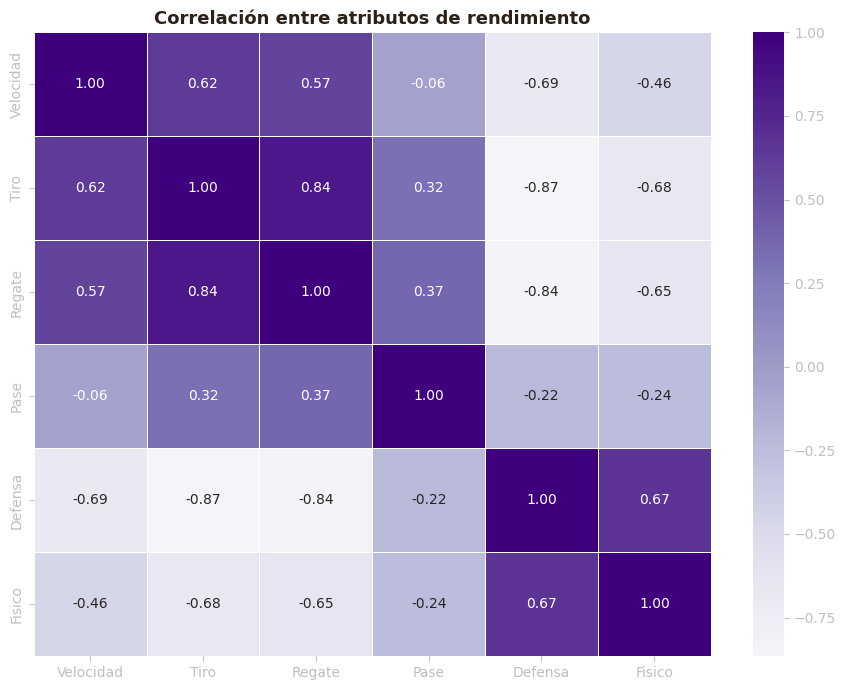

In [24]:
# Correlación entre atributos
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    df[atributos].corr(),
    annot=True,
    fmt=".2f",
    cmap="Purples",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlación entre atributos de rendimiento")
plt.tight_layout()
plt.show()


### Lectura del EDA

Las medias por posición ya anticipan una estructura interpretable: los **defensas** destacan especialmente en Defensa y Físico; los **delanteros** en Velocidad, Tiro y Regate; y los **centrocampistas** presentan un perfil más equilibrado, con especial peso del Pase.

Esto hace especialmente adecuado el SOM: el objetivo no es imponer estas categorías, sino comprobar si aparecen de forma natural al organizar los jugadores por similitud.


## 4. Preparación de datos

El SOM utiliza distancias entre jugadores. Por ello, estandarizamos los seis atributos para que todos tengan **media 0 y desviación estándar 1**.

`Posicion_Real` queda fuera del entrenamiento y se conserva únicamente para interpretar posteriormente el mapa.


In [25]:
# Matriz de entrada y estandarización
X = df[atributos].values

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

print(f"Shape original: {X.shape}")
print(f"Shape escalado: {X_sc.shape}")
print(f"Media absoluta máxima tras escalar: {np.abs(X_sc.mean(axis=0)).max():.6f}")
print(f"Desviación estándar media: {X_sc.std(axis=0).mean():.2f}")


Shape original: (800, 6)
Shape escalado: (800, 6)
Media absoluta máxima tras escalar: 0.000000
Desviación estándar media: 1.00


## 5. Modelo principal

Se construye una rejilla de **12 × 12 = 144 neuronas** para 800 jugadores. Cada neurona aprende un prototipo de perfil y el entrenamiento organiza los perfiles similares en zonas próximas del mapa.

La configuración utilizada es `sigma=2.0`, `learning_rate=0.5` y **5.000 iteraciones**.


In [26]:
# Construcción y entrenamiento del SOM
np.random.seed(42)

som = MiniSom(
    x=12,
    y=12,
    input_len=X_sc.shape[1],
    sigma=2.0,
    learning_rate=0.5,
    neighborhood_function="gaussian",
    random_seed=42
)

som.random_weights_init(X_sc)
som.train_random(X_sc, num_iteration=5000)

quant_error = som.quantization_error(X_sc)

print("Entrenamiento completado")
print(f"Iteraciones: 5.000")
print(f"Neurona: 12 × 12 = 144")
print(f"Error de cuantización: {quant_error:.4f}")


Entrenamiento completado
Iteraciones: 5.000
Neurona: 12 × 12 = 144
Error de cuantización: 0.6789


### 5.1. U-Matrix — estructura y separación

La **U-Matrix** representa la distancia entre neuronas vecinas. Las zonas con valores altos funcionan como fronteras: indican cambios más fuertes entre perfiles.


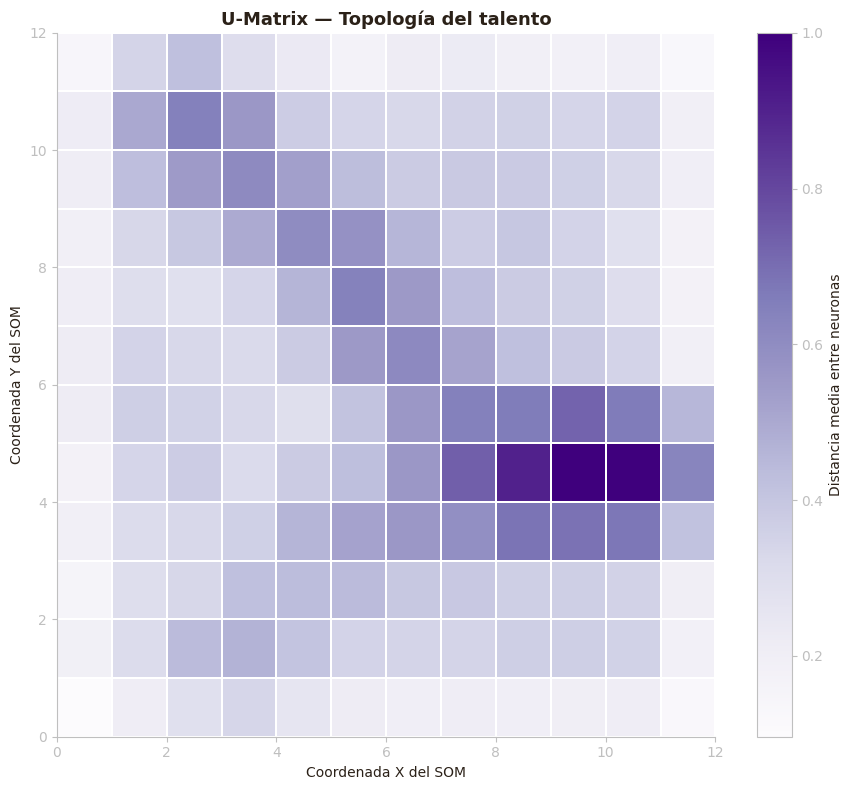

In [27]:
# U-Matrix
umatrix = som.distance_map()

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.pcolormesh(
    umatrix.T,
    cmap="Purples",
    edgecolors="white",
    linewidth=0.3
)

ax.set_title("U-Matrix — Topología del talento")
ax.set_xlabel("Coordenada X del SOM")
ax.set_ylabel("Coordenada Y del SOM")
fig.colorbar(im, ax=ax, label="Distancia media entre neuronas")

plt.tight_layout()
plt.show()


### 5.2. Mapa SOM con las posiciones reales

Superponemos la posición real únicamente para **validar visualmente** si las zonas descubiertas por el SOM coinciden con los perfiles tácticos conocidos.


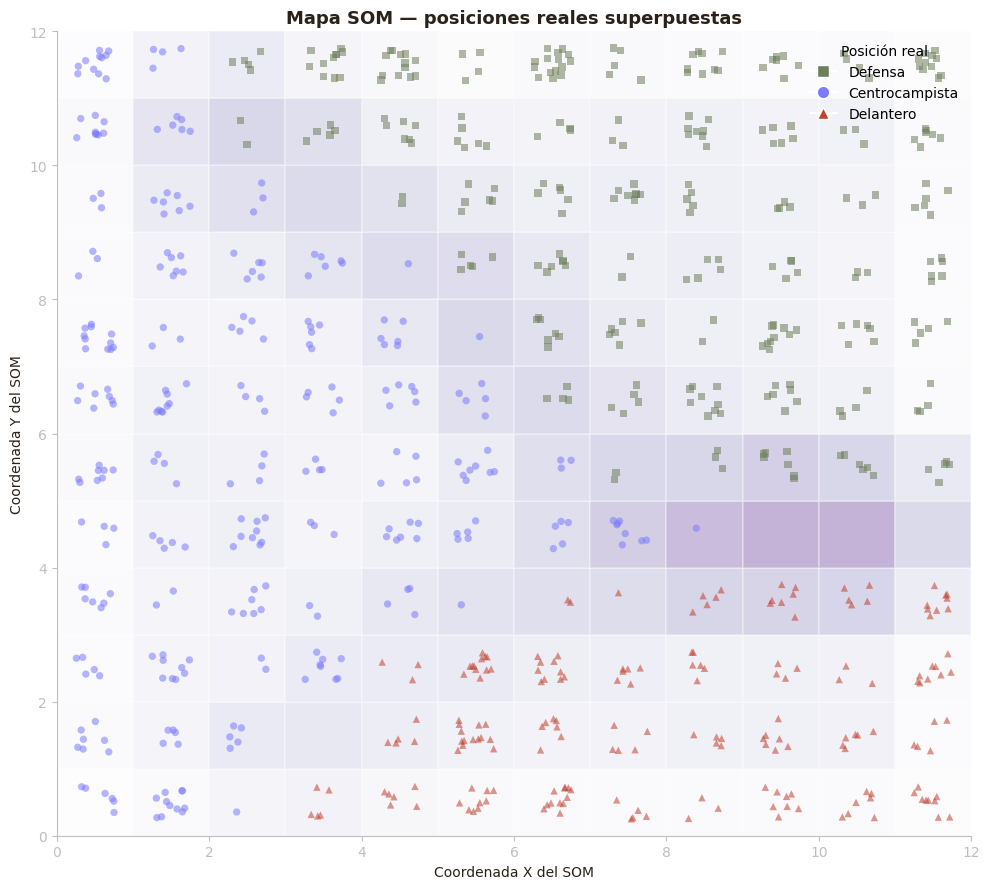

In [28]:
# Mapa SOM + posición real
marcadores_pos = {
    "Defensa": "s",
    "Centrocampista": "o",
    "Delantero": "^"
}

fig, ax = plt.subplots(figsize=(10, 9))

ax.pcolormesh(
    umatrix.T,
    cmap="Purples",
    alpha=0.30,
    edgecolors="white",
    linewidth=0.3
)

rng = np.random.default_rng(42)

for i, x in enumerate(X_sc):
    w = som.winner(x)
    pos = df.iloc[i]["Posicion_Real"]

    ax.scatter(
        w[0] + 0.5 + rng.uniform(-0.25, 0.25),
        w[1] + 0.5 + rng.uniform(-0.25, 0.25),
        marker=marcadores_pos[pos],
        color=colores_pos[pos],
        s=28,
        alpha=0.55,
        edgecolors="none"
    )

from matplotlib.lines import Line2D
legend_elements = [
    Line2D(
        [0], [0],
        marker=marcadores_pos[pos],
        color="w",
        markerfacecolor=color,
        markersize=9,
        label=pos
    )
    for pos, color in colores_pos.items()
]

ax.legend(handles=legend_elements, title="Posición real", frameon=False)
ax.set_title("Mapa SOM — posiciones reales superpuestas")
ax.set_xlabel("Coordenada X del SOM")
ax.set_ylabel("Coordenada Y del SOM")

plt.tight_layout()
plt.show()


### 5.3. Component Planes

Cada **Component Plane** muestra cómo se distribuye una variable dentro del mapa. La lectura conjunta permite entender qué habilidades definen cada región y por qué determinados jugadores terminan cerca.


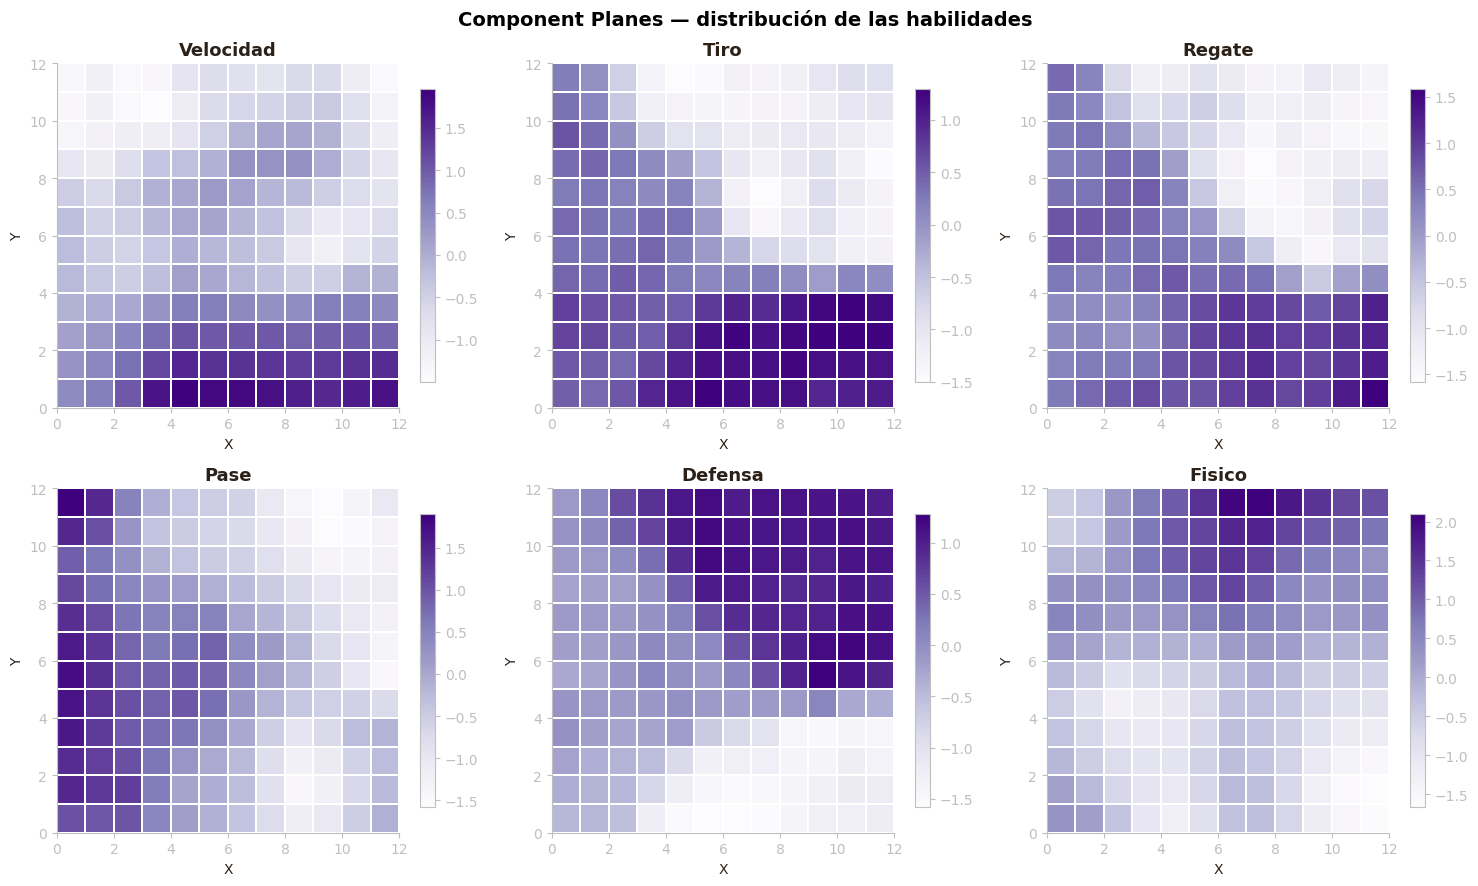

In [29]:
# Component Planes
weights = som.get_weights()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, attr, i in zip(axes.flat, atributos, range(len(atributos))):
    im = ax.pcolormesh(
        weights[:, :, i].T,
        cmap="Purples",
        edgecolors="white",
        linewidth=0.2
    )
    ax.set_title(attr)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    fig.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle("Component Planes — distribución de las habilidades", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Lectura del mapa

El SOM permite interpretar el talento como un continuo. No solo aparecen zonas asociadas a defensas, centrocampistas y delanteros: también aparecen **zonas intermedias** donde los perfiles comparten características de varias posiciones.

Esta es una de las principales ventajas del SOM frente a una clasificación rígida: la posición deja de ser una frontera absoluta y pasa a formar parte de un espacio de similitud.


## 6. Modelo alternativo — PCA para validación

Utilizamos **PCA 2D** como referencia lineal. No sustituye al SOM: sirve para comprobar cuánto de la estructura de las seis variables puede observarse mediante una proyección lineal.


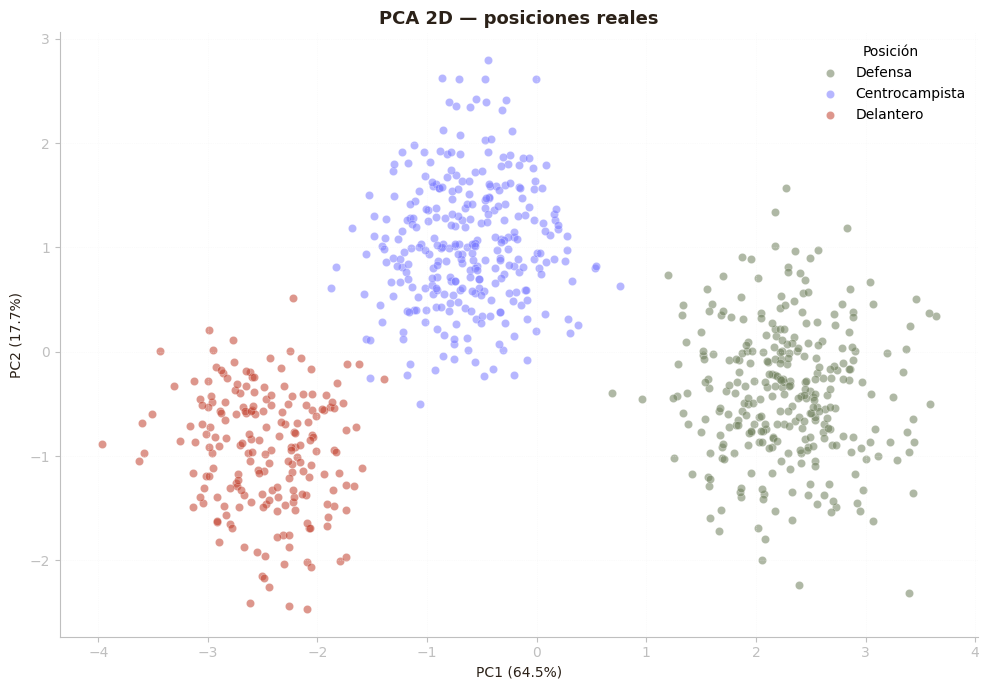

Varianza explicada total por PCA: 82.2%


In [30]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(10, 7))

for pos, color in colores_pos.items():
    mask = df["Posicion_Real"] == pos
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=color,
        label=pos,
        alpha=0.55,
        s=35,
        edgecolors="white",
        linewidths=0.3
    )

ax.set_title("PCA 2D — posiciones reales")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(title="Posición", frameon=False)
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Varianza explicada total por PCA: {pca.explained_variance_ratio_.sum():.1%}")


### SOM frente a PCA

PCA resume la información en dos ejes lineales y permite visualizar la separación global. El SOM aporta algo diferente: además de reducir la dimensionalidad, **preserva relaciones de vecindad** y permite estudiar qué variables dominan cada región mediante los Component Planes.


## 7. Análisis de jugadores versátiles

Una aplicación práctica del mapa es localizar jugadores próximos a **fronteras entre perfiles**. Como aproximación exploratoria, utilizamos la distancia de la U-Matrix asociada a la neurona ganadora de cada jugador.

> Una puntuación alta se interpreta como una señal de posible transición entre regiones; no es una medida definitiva de versatilidad táctica.


In [31]:
# Puntuación exploratoria de versatilidad basada en la U-Matrix
versatilidad = []

for x in X_sc:
    w = som.winner(x)
    versatilidad.append(umatrix[w[0], w[1]])

df["Versatilidad_SOM"] = versatilidad

top = (
    df.nlargest(10, "Versatilidad_SOM")
      [["Posicion_Real", *atributos, "Versatilidad_SOM"]]
)

print("Top 10 perfiles situados en zonas de transición del SOM:")
display(top.round(1))


Top 10 perfiles situados en zonas de transición del SOM:


,Posicion_Real,Velocidad,Tiro,Regate,Pase,Defensa,Fisico,Versatilidad_SOM
527,Centrocampista,67.2,60.8,68.1,74.5,57.7,70.9,0.9
328,Centrocampista,68.8,71.8,78.6,67.4,63.9,71.2,0.7
419,Centrocampista,69.2,67.0,75.5,71.7,58.6,64.9,0.7
432,Centrocampista,69.7,65.3,80.1,71.5,56.4,71.3,0.7
507,Centrocampista,66.5,66.3,79.3,72.7,67.0,68.0,0.7
523,Centrocampista,72.8,63.4,80.1,72.2,59.4,66.4,0.7
548,Centrocampista,66.2,63.3,83.5,70.1,67.7,72.0,0.7
559,Centrocampista,66.4,64.0,75.5,72.2,62.7,64.1,0.7
567,Centrocampista,71.2,64.4,77.6,69.8,64.1,70.8,0.7
36,Defensa,59.6,38.3,46.6,65.6,99.0,66.9,0.7


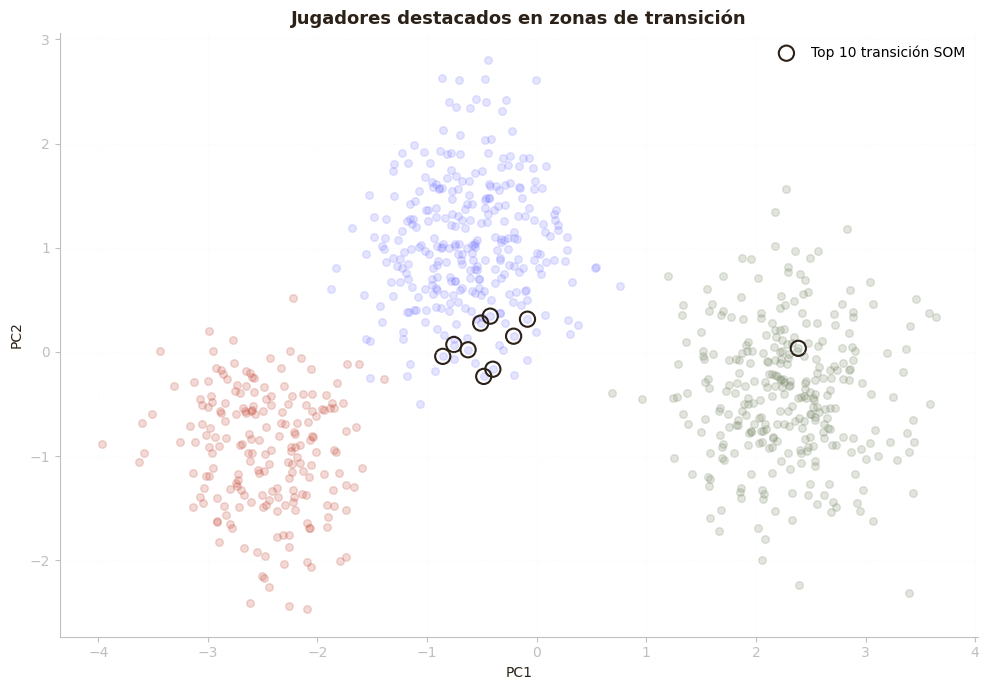

In [32]:
# Visualización de los perfiles más cercanos a zonas de transición
top_idx = df.nlargest(10, "Versatilidad_SOM").index

fig, ax = plt.subplots(figsize=(10, 7))

for pos, color in colores_pos.items():
    mask = df["Posicion_Real"] == pos
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=color,
        alpha=0.20,
        s=30
    )

ax.scatter(
    X_pca[top_idx, 0],
    X_pca[top_idx, 1],
    facecolors="none",
    edgecolors=INK,
    s=120,
    linewidths=1.5,
    label="Top 10 transición SOM"
)

ax.set_title("Jugadores destacados en zonas de transición")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(frameon=False)
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


## 8. Comparación de métodos

| Método | Topología | Descubre arquetipos | Validación visual |
|:-------|:----------|:--------------------|:------------------|
| **SOM (12×12)** | Sí | Sí, mediante Component Planes | Excelente |
| **PCA 2D** | No | Parcial | Buena |

La comparación no busca declarar un ganador únicamente por una métrica. PCA es una reducción lineal; el SOM está diseñado para **organizar perfiles similares conservando su vecindad**.


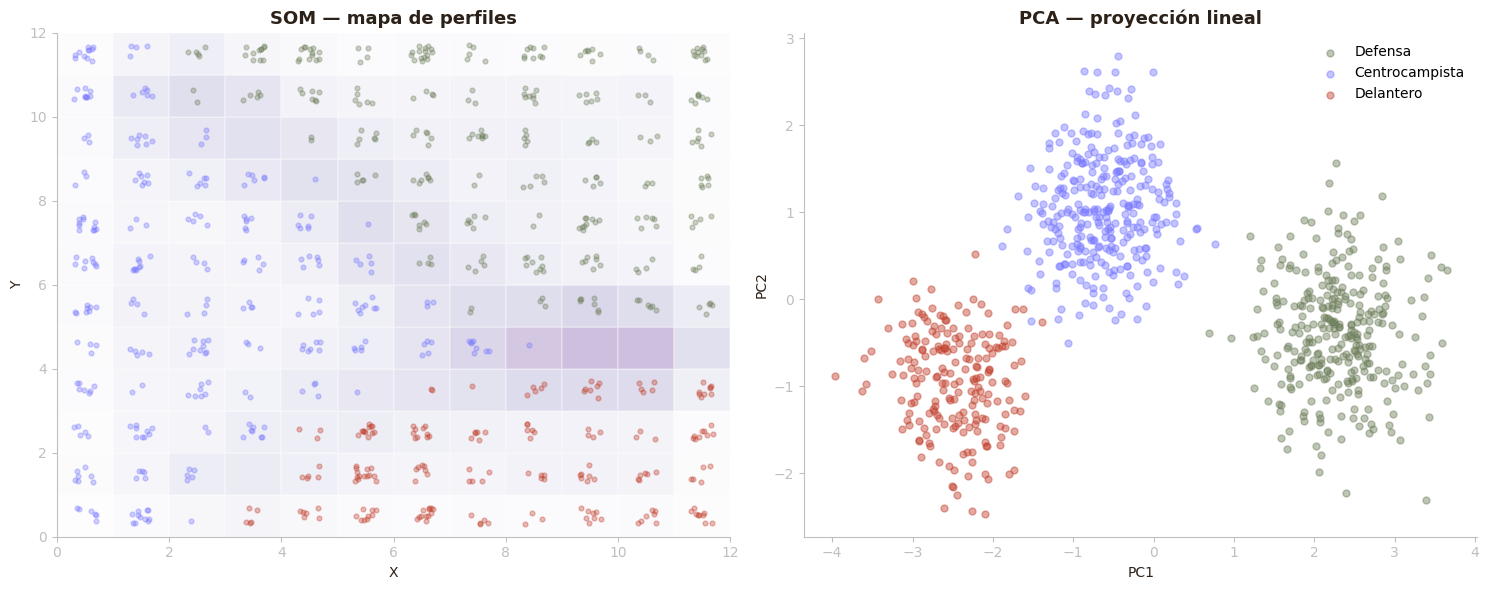

In [33]:
# Comparación visual compacta
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# SOM
axes[0].pcolormesh(
    umatrix.T,
    cmap="Purples",
    alpha=0.25,
    edgecolors="white",
    linewidth=0.3
)

rng = np.random.default_rng(42)
for i, x in enumerate(X_sc):
    w = som.winner(x)
    pos = df.iloc[i]["Posicion_Real"]
    axes[0].scatter(
        w[0] + 0.5 + rng.uniform(-0.2, 0.2),
        w[1] + 0.5 + rng.uniform(-0.2, 0.2),
        color=colores_pos[pos],
        s=12,
        alpha=0.35
    )

axes[0].set_title("SOM — mapa de perfiles")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# PCA
for pos, color in colores_pos.items():
    mask = df["Posicion_Real"] == pos
    axes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=color,
        label=pos,
        alpha=0.45,
        s=25
    )

axes[1].set_title("PCA — proyección lineal")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 9. Insights y recomendaciones accionables

### Hallazgo clave

El SOM permite observar una estructura coherente del talento: los perfiles defensivos, de centro del campo y ofensivos tienden a ocupar **regiones diferenciadas**, mientras que las zonas de transición muestran jugadores con combinaciones de habilidades menos puras.

### Recomendaciones

**1. Scouting basado en vecindad — impacto alto**  
Utilizar las neuronas próximas a un jugador de referencia para ampliar la búsqueda de candidatos similares, en lugar de limitarse a filtros independientes.

**2. Identificación de perfiles polivalentes — impacto alto**  
Revisar jugadores situados en zonas de transición para detectar futbolistas cuyo perfil pueda encajar en más de una función táctica.

**3. Detección de oportunidades de mercado — impacto medio/alto**  
Combinar el mapa de perfiles con precio, edad, contrato o disponibilidad para buscar jugadores que sean similares a un arquetipo objetivo pero tengan menor coste de adquisición.

**4. Herramienta de scouting interactiva — impacto medio**  
Llevar el mapa a Plotly o Power BI para permitir al director deportivo explorar cada neurona y consultar el perfil completo de los jugadores.


## 10. Conclusión

El **SOM es especialmente útil en este problema porque convierte seis dimensiones de rendimiento en un mapa donde la proximidad tiene significado**.

Los resultados muestran que la estructura aprendida es coherente con las posiciones reales, pero el valor del modelo va más allá de reproducir categorías conocidas: permite visualizar **zonas intermedias, perfiles híbridos y relaciones entre jugadores** que un filtro tradicional puede pasar por alto.

PCA confirma que existe una estructura global bastante clara en los datos, pero el SOM ofrece una lectura más rica al conservar la topología y permitir analizar cada variable mediante Component Planes.

### Recomendación final

Para scouting, utilizaría el **SOM como herramienta de exploración y descubrimiento**, complementándolo con información externa —edad, coste, contrato, historial de lesiones y rendimiento reciente— antes de tomar decisiones de fichaje. El siguiente paso natural sería construir un **dashboard interactivo de scouting** sobre el mapa SOM.
